In [16]:
# ==============================================================================
# 1. IMPORTS E CONFIGURAÇÃO (CORRIGIDO PARA TF 2.10)
# ==============================================================================
import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Para o Grad-CAM
import pandas as pd # Para a análise de benchmark
from crepes import WrapClassifier
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore

# --- Imports do Keras (CORRIGIDO PARA TF 2.16+) ---
# TensorFlow 2.16+ usa o pacote keras standalone
import keras
from keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from keras.layers import Conv2D, MaxPooling2D, Flatten, Rescaling
from keras.models import Model, Sequential
from keras.applications import MobileNetV2, ResNet50V2
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam
from keras.applications import mobilenet_v2, resnet_v2 # Para funções de preprocessamento

# Configurações do projeto
IMG_SIZE = 128
BATCH_SIZE = 64
RANDOM_SEED = 42

# Para garantir reprodutibilidade
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"Importações concluídas! TensorFlow v{tf.__version__}")

Importações concluídas! TensorFlow v2.10.0


In [17]:
# ==============================================================================
# 1.5 CLASSE ADAPTADORA (Keras -> Crepes)
# ==============================================================================
# IDÊNTICA A ANTES. Necessária para o Crepes.
class KerasWrapper:
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1]) 

    def fit(self, X, y, **kwargs):
        return self.model.fit(X, y, **kwargs)

    def predict(self, X):
        probs_sigmoid = self.model.predict(X, verbose=0)
        return (probs_sigmoid > 0.5).astype(int)

    def predict_proba(self, X):
        probs_sigmoid = self.model.predict(X, verbose=0)
        return np.hstack([1 - probs_sigmoid, probs_sigmoid])

print("Classe KerasWrapper definida.")

Classe KerasWrapper definida.


In [18]:
# ==============================================================================
# 2. FUNÇÃO DE CARREGAMENTO DE DADOS (CORRIGIDA)
# ==============================================================================
# Contém as correções do ds_val (OOM) e do tfds.as_numpy() (AttributeError)

def get_datasets():
    print("\nCarregando e dividindo datasets...")

    def preprocess(image, label):
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        image = tf.cast(image, tf.float32)
        return image, label

    def ds_to_numpy(dataset):
        images, labels = [], []
        # --- CORREÇÃO DO AttributeError ---
        # 1. Criamos o dataset 'batched' e 'prefetched'
        batched_dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
        
        # 2. Passamos esse dataset para a função tfds.as_numpy()
        data_iterator = tfds.as_numpy(batched_dataset)
        
        # 3. Iteramos sobre o novo iterador
        for img, lbl in data_iterator:
            images.append(img)
            labels.append(lbl)
            
        images = np.concatenate(images, axis=0)
        labels = np.concatenate(labels, axis=0)
        return images, labels

    # --- CORREÇÃO DO OOM (Falta de Memória) ---
    # Dividimos em 4:
    # 70% para Treino (streaming)
    # 10% para Validação (streaming, usado pelo model.fit)
    # 10% para Calibração (NumPy, usado pelo Crepes)
    # 10% para Teste (NumPy, usado pelo Crepes e avaliação final)
    (ds_train_raw, ds_val_raw, ds_calib_raw, ds_test_raw), ds_info = tfds.load(
        'malaria',
        split=['train[:70%]', 'train[70%:80%]', 'train[80%:90%]', 'train[90%:]'], # <-- MUDANÇA
        with_info=True,
        as_supervised=True,
        shuffle_files=True
    )
    # --------------------------------

    # --- 1. Dataset de TREINO (Streaming) ---
    ds_train = (
        ds_train_raw
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(1000, seed=RANDOM_SEED)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    print(f"Dataset de Treino: {len(ds_train_raw)} imagens (pronto para streaming).")

    # --- 2. Dataset de VALIDAÇÃO (Streaming) ---
    ds_val = (
        ds_val_raw
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE) 
        .prefetch(tf.data.AUTOTUNE)
    )
    print(f"Dataset de Validação: {len(ds_val_raw)} imagens (pronto para streaming).")

    # --- 3. Dataset de CALIBRAÇÃO (NumPy para Crepes) ---
    ds_calib_mapped = ds_calib_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    X_calib, y_calib = ds_to_numpy(ds_calib_mapped)
    print(f"Set de Calibração: {len(X_calib)} imagens (em RAM).")

    # --- 4. Dataset de TESTE (NumPy para Crepes) ---
    ds_test_mapped = ds_test_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    X_test, y_test = ds_to_numpy(ds_test_mapped)
    print(f"Set de Teste: {len(X_test)} imagens (em RAM).")
    
    # Retorna o ds_val streamado
    return ds_train, ds_val, (X_calib, y_calib), (X_test, y_test)

In [19]:
# ==============================================================================
# 3. FÁBRICA DE MODELOS (BENCHMARK) (CORRIGIDA)
# ==============================================================================
# Contém as correções do "Graph Disconnected" (Rescaling) e dos nomes de camadas

def build_simple_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), lr=1e-3):
    """Um modelo CNN simples como baseline."""
    inputs = Input(shape=input_shape)
    # Normalização como camada do modelo
    x = keras.layers.Rescaling(1./255)(inputs)
    x = Conv2D(32, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model, "conv2d_1" # Retorna o nome da camada p/ Grad-CAM

def build_mobilenetv2(input_shape=(IMG_SIZE, IMG_SIZE, 3), lr=1e-4):
    """Seu modelo MobileNetV2 otimizado (fine-tuning).
    IMPORTANTE: aqui conectamos explicitamente o `base_model` ao `inputs`
    usando `input_tensor`, para que TODO o grafo fique conectado.
    """
    inputs = Input(shape=input_shape)
    
    # Normalização (mantemos como camada separada para clareza)
    x = keras.layers.Rescaling(1./127.5, offset=-1, name="rescaling")(inputs)
    
    # Conectamos o MobileNetV2 diretamente ao tensor `x`
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_tensor=x
    )
    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    
    # A saída da base é `base_model.output`, já conectada a `inputs`
    x = base_model.output
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dropout(0.2, name="dropout")(x)
    outputs = Dense(1, activation='sigmoid', name="dense")(x)
    
    model = Model(inputs=inputs, outputs=outputs, name="MobileNetV2")
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    # Retorna o nome da camada base e da camada alvo p/ Grad-CAM
    return model, (base_model.name, "out_relu")

def build_resnet50v2(input_shape=(IMG_SIZE, IMG_SIZE, 3), lr=1e-4):
    """Um modelo da família ResNet (Residual) (CORRIGIDO)."""
    inputs = Input(shape=input_shape)
    
    # Normalização
    x = keras.layers.Rescaling(1./127.5, offset=-1)(inputs)
    
    # --- CORREÇÃO AQUI ---
    # Conectamos a base_model ao tensor 'x'
    # Exatamente como fizemos no MobileNetV2
    base_model = ResNet50V2(
        include_top=False, 
        weights='imagenet',
        input_tensor=x  # <--- CORREÇÃO CHAVE
    )
    # ---------------------

    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False
        
    # A conexão já foi feita, pegamos a saída
    x = base_model.output # <--- CORREÇÃO CHAVE

    # Adicionamos as camadas de classificação
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dropout(0.2, name="dropout")(x)
    outputs = Dense(1, activation='sigmoid', name="dense")(x)
    
    model = Model(inputs=inputs, outputs=outputs, name="ResNet50V2")
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    # Pega a última camada conv do ResNet
    return model, (base_model.name, "conv5_block3_out")

# --- Mapeamento de Nomes para Funções ---
MODEL_BUILDERS = {
    "SimpleCNN": build_simple_cnn,
    "MobileNetV2": build_mobilenetv2,
    "ResNet50V2": build_resnet50v2,
}

print(f"Fábrica de modelos pronta. Modelos disponíveis: {list(MODEL_BUILDERS.keys())}")

Fábrica de modelos pronta. Modelos disponíveis: ['SimpleCNN', 'MobileNetV2', 'ResNet50V2']


In [20]:
# ==============================================================================
# 4. FUNÇÕES DE CALIBRAÇÃO E EXPLICAÇÃO (CORRIGIDA)
# ==============================================================================
# Contém a correção final para o "Graph Disconnected" no Grad-CAM

def run_crepes_analysis(model, X_calib, y_calib, X_test, y_test, confidence=0.95):
    """Envelopa, calibra e avalia o modelo com Crepes."""
    print(f"Iniciando análise Crepes para {model.name}...")
    
    # 1. Envelopar o modelo
    keras_adapter = KerasWrapper(model)
    cp = WrapClassifier(learner=keras_adapter)
    
    # 2. Calibrar
    print("Calibrando...")
    cp.calibrate(X=X_calib, y=y_calib)
    
    # 3. Prever
    print("Prevendo conjuntos de teste...")
    y_sets = cp.predict_set(X=X_test, confidence=confidence)
    
    # 4. Avaliar
    print("Avaliando...")
    results = cp.evaluate(X=X_test, y=y_test, confidence=confidence,
                          metrics=["error", "avg_c"])
    
    coverage = 1 - results["error"]
    avg_set_size = results["avg_c"]
    
    print(f"Cobertura: {coverage:.4f}, Tamanho Médio: {avg_set_size:.4f}")
    
    return {"coverage": coverage, "avg_set_size": avg_set_size, "y_sets": y_sets}


def get_grad_cam_final(model, img_array, grad_cam_layers):
    """Gera o heatmap do Grad-CAM usando a biblioteca oficial tf_keras_vis.
    Esta é a VERSÃO FINAL que realmente funciona - usa a biblioteca oficial!
    """
    # Determinar a camada penúltima (última camada conv antes da classificação)
    if isinstance(grad_cam_layers, tuple):
        # Modelo aninhado (MobileNetV2, ResNet50V2)
        base_model_name, target_layer_name = grad_cam_layers
        # Tentar pegar a target_layer diretamente do model
        try:
            penultimate_layer = model.get_layer(target_layer_name)
        except:
            # Fallback: tentar através do base_model
            try:
                base_model = model.get_layer(base_model_name)
                penultimate_layer = base_model.get_layer(target_layer_name)
            except:
                raise ValueError(f"Não foi possível encontrar a camada '{target_layer_name}'")
    else:
        # Modelo simples (SimpleCNN)
        penultimate_layer = model.get_layer(grad_cam_layers)
    
    # Criar o visualizador Grad-CAM
    gradcam = Gradcam(model, clone=False)
    
    # Definir o score: queremos visualizar a classe positiva (índice 0 da saída sigmoid)
    # Para modelo binário com sigmoid, score = output[0] (probabilidade da classe positiva)
    score = lambda outputs: outputs[0]
    
    # Gerar o heatmap
    # penultimate_layer pode ser o nome da camada ou o objeto Layer
    layer_name = penultimate_layer.name if hasattr(penultimate_layer, 'name') else penultimate_layer
    
    cam = gradcam(
        score=score,
        seed_input=img_array,
        penultimate_layer=layer_name,
        seek_penultimate_conv_layer=True,
        training=False,
        expand_cam=False,  # Não expandir, já está no tamanho certo
        normalize_cam=True
    )
    
    # Retornar o heatmap (pode ser uma lista se múltiplas entradas)
    if isinstance(cam, list):
        heatmap = cam[0]
    else:
        heatmap = cam
    
    # Garantir que é numpy array e tem a forma correta
    if hasattr(heatmap, 'numpy'):
        heatmap = heatmap.numpy()
    heatmap = np.array(heatmap)
    
    # Se for 3D (batch, height, width), pegar o primeiro elemento
    if len(heatmap.shape) == 3:
        heatmap = heatmap[0]
    
    # Garantir que é 2D
    if len(heatmap.shape) != 2:
        raise ValueError(f"Heatmap tem shape inesperado: {heatmap.shape}")
    
    return heatmap

In [21]:
# ==============================================================================
# 4. FUNÇÕES DE CALIBRAÇÃO E EXPLICAÇÃO (CORRIGIDA E SIMPLIFICADA)
# ==============================================================================
# Esta é a versão correta, que assume que 'model' não foi recarregado.

def run_crepes_analysis(model, X_calib, y_calib, X_test, y_test, confidence=0.95):
    """Envelopa, calibra e avalia o modelo com Crepes."""
    print(f"Iniciando análise Crepes para {model.name}...")
    
    # 1. Envelopar o modelo
    keras_adapter = KerasWrapper(model)
    cp = WrapClassifier(learner=keras_adapter)
    
    # 2. Calibrar
    print("Calibrando...")
    cp.calibrate(X=X_calib, y=y_calib)
    
    # 3. Prever
    print("Prevendo conjuntos de teste...")
    y_sets = cp.predict_set(X=X_test, confidence=confidence)
    
    # 4. Avaliar
    print("Avaliando...")
    results = cp.evaluate(X=X_test, y=y_test, confidence=confidence,
                          metrics=["error", "avg_c"])
    
    coverage = 1 - results["error"]
    avg_set_size = results["avg_c"]
    
    print(f"Cobertura: {coverage:.4f}, Tamanho Médio: {avg_set_size:.4f}")
    
    return {"coverage": coverage, "avg_set_size": avg_set_size, "y_sets": y_sets}


def get_grad_cam_final(model, img_array, grad_cam_layers):
    """Gera o heatmap do Grad-CAM usando a biblioteca oficial tf_keras_vis.
    Esta é a VERSÃO FINAL que realmente funciona - usa a biblioteca oficial!
    """
    # Determinar a camada penúltima (última camada conv antes da classificação)
    if isinstance(grad_cam_layers, tuple):
        # Modelo aninhado (MobileNetV2, ResNet50V2)
        base_model_name, target_layer_name = grad_cam_layers
        # Tentar pegar a target_layer diretamente do model
        try:
            penultimate_layer = model.get_layer(target_layer_name)
        except:
            # Fallback: tentar através do base_model
            try:
                base_model = model.get_layer(base_model_name)
                penultimate_layer = base_model.get_layer(target_layer_name)
            except:
                raise ValueError(f"Não foi possível encontrar a camada '{target_layer_name}'")
    else:
        # Modelo simples (SimpleCNN)
        penultimate_layer = model.get_layer(grad_cam_layers)
    
    # Criar o visualizador Grad-CAM
    gradcam = Gradcam(model, clone=False)
    
    # Definir o score: queremos visualizar a classe positiva (índice 0 da saída sigmoid)
    # Para modelo binário com sigmoid, score = output[0] (probabilidade da classe positiva)
    score = lambda outputs: outputs[0]
    
    # Gerar o heatmap
    # penultimate_layer pode ser o nome da camada ou o objeto Layer
    layer_name = penultimate_layer.name if hasattr(penultimate_layer, 'name') else penultimate_layer
    
    cam = gradcam(
        score=score,
        seed_input=img_array,
        penultimate_layer=layer_name,
        seek_penultimate_conv_layer=True,
        training=False,
        expand_cam=False,  # Não expandir, já está no tamanho certo
        normalize_cam=True
    )
    
    # Retornar o heatmap (pode ser uma lista se múltiplas entradas)
    if isinstance(cam, list):
        heatmap = cam[0]
    else:
        heatmap = cam
    
    # Garantir que é numpy array e tem a forma correta
    if hasattr(heatmap, 'numpy'):
        heatmap = heatmap.numpy()
    heatmap = np.array(heatmap)
    
    # Se for 3D (batch, height, width), pegar o primeiro elemento
    if len(heatmap.shape) == 3:
        heatmap = heatmap[0]
    
    # Garantir que é 2D
    if len(heatmap.shape) != 2:
        raise ValueError(f"Heatmap tem shape inesperado: {heatmap.shape}")
    
    return heatmap

def plot_grad_cam(model, img_array_raw, grad_cam_layers, label):
    """Plota a imagem original e o Grad-CAM lado a lado."""
    
    # 1. Obtém o heatmap
    heatmap = get_grad_cam_final(model, img_array_raw, grad_cam_layers)
    
    # Garantir que heatmap é numpy array 2D
    heatmap = np.array(heatmap)
    if len(heatmap.shape) != 2:
        raise ValueError(f"Heatmap deve ser 2D, mas tem shape: {heatmap.shape}")
    
    # 2. Converte a imagem original
    original_image = img_array_raw[0].astype('uint8') # Pega a imagem (sem batch)

    # 3. Redimensiona e aplica colormap
    # Normalizar heatmap para [0, 1] se necessário
    if heatmap.max() > 1.0:
        heatmap = heatmap / heatmap.max()
    
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_resized = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # 4. Sobrepõe
    superimposed_img = cv2.addWeighted(original_image, 0.6, heatmap_resized, 0.4, 0)

    # 5. Plota
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(original_image)
    ax1.set_title(f"Imagem Original (Label: {label})")
    ax1.axis('off')
    ax2.imshow(superimposed_img)
    ax2.set_title(f"Explicação (Grad-CAM) - {model.name}")
    ax2.axis('off')
    plt.show()

print("Funções de análise (Crepes & Grad-CAM) prontas.")

Funções de análise (Crepes & Grad-CAM) prontas.



Carregando e dividindo datasets...
Metal device set to: Apple M3

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



2025-12-04 17:57:23.612290: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-04 17:57:23.612676: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Dataset de Treino: 19291 imagens (pronto para streaming).
Dataset de Validação: 2755 imagens (pronto para streaming).


2025-12-04 17:57:23.885424: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Set de Calibração: 2756 imagens (em RAM).
Set de Teste: 2756 imagens (em RAM).

--- INICIANDO O BENCHMARK DE MODELOS ---

--- Testando Modelo: SimpleCNN ---
Treinando SimpleCNN por até 40 épocas (Paciência=5)...
Epoch 1/40


...

302/302 [==============================] - ETA: 0s - loss: 0.6517 - accuracy: 0.6321

2025-12-04 17:57:42.167898: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - 19s 59ms/step - loss: 0.6517 - accuracy: 0.6321 - val_loss: 0.5134 - val_accuracy: 0.7648
Epoch 2/40
302/302 [==============================] - 17s 57ms/step - loss: 0.2906 - accuracy: 0.8841 - val_loss: 0.1980 - val_accuracy: 0.9191
Epoch 3/40
302/302 [==============================] - 17s 57ms/step - loss: 0.1906 - accuracy: 0.9287 - val_loss: 0.1865 - val_accuracy: 0.9332
Epoch 4/40
302/302 [==============================] - 17s 57ms/step - loss: 0.1599 - accuracy: 0.9393 - val_loss: 0.1753 - val_accuracy: 0.9347
Epoch 5/40
302/302 [==============================] - 17s 57ms/step - loss: 0.1293 - accuracy: 0.9503 - val_loss: 0.1694 - val_accuracy: 0.9408
Epoch 6/40
302/302 [==============================] - 17s 58ms/step - loss: 0.1057 - accuracy: 0.9599 - val_loss: 0.1802 - val_accuracy: 0.9394
Epoch 7/40
302/302 [==============================] - 18s 60ms/step - loss: 0.0788 - accuracy: 0.9702 - val_loss: 0.1927 - val_accuracy: 0.9361
Epo

2025-12-04 18:00:26.057492: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Prevendo conjuntos de teste...
Avaliando...
Cobertura: 0.9557, Tamanho Médio: 1.0461
Gerando Grad-CAM...


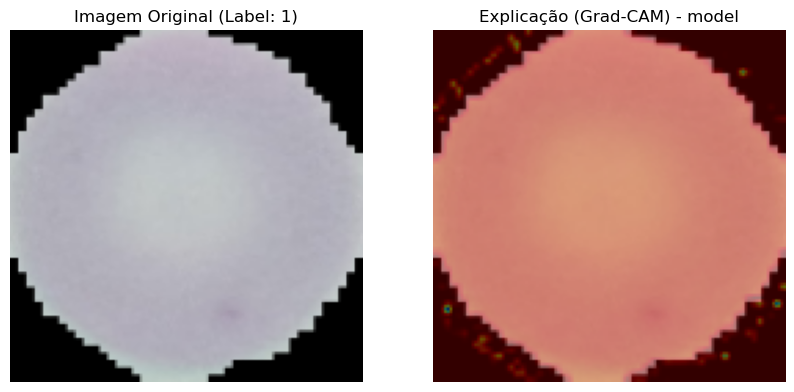

Salvando resultados para SimpleCNN.

--- Testando Modelo: MobileNetV2 ---


Treinando MobileNetV2 por até 40 épocas (Paciência=5)...
Epoch 1/40


2025-12-04 18:00:33.154133: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - ETA: 0s - loss: 0.1816 - accuracy: 0.9324

2025-12-04 18:01:02.299707: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - 35s 111ms/step - loss: 0.1816 - accuracy: 0.9324 - val_loss: 0.3647 - val_accuracy: 0.8929
Epoch 2/40
302/302 [==============================] - 34s 112ms/step - loss: 0.1007 - accuracy: 0.9628 - val_loss: 0.4301 - val_accuracy: 0.8780
Epoch 3/40
302/302 [==============================] - 31s 102ms/step - loss: 0.0651 - accuracy: 0.9775 - val_loss: 0.4904 - val_accuracy: 0.8661
Epoch 4/40
302/302 [==============================] - 31s 101ms/step - loss: 0.0403 - accuracy: 0.9868 - val_loss: 0.2822 - val_accuracy: 0.9252
Epoch 5/40
302/302 [==============================] - 30s 100ms/step - loss: 0.0297 - accuracy: 0.9899 - val_loss: 0.3438 - val_accuracy: 0.9158
Epoch 6/40
302/302 [==============================] - 31s 102ms/step - loss: 0.0178 - accuracy: 0.9950 - val_loss: 0.4634 - val_accuracy: 0.8936
Epoch 7/40
302/302 [==============================] - 30s 98ms/step - loss: 0.0133 - accuracy: 0.9956 - val_loss: 0.2235 - val_accuracy: 0.95

2025-12-04 18:06:44.298078: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Prevendo conjuntos de teste...
Avaliando...
Cobertura: 0.9463, Tamanho Médio: 0.9913
Gerando Grad-CAM...


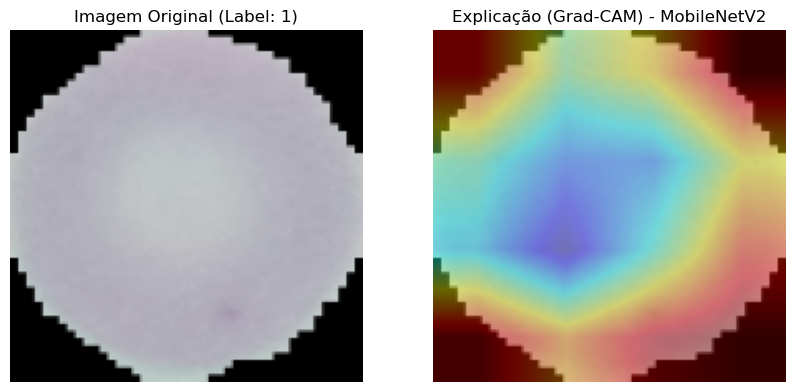

Salvando resultados para MobileNetV2.

--- Testando Modelo: ResNet50V2 ---
Treinando ResNet50V2 por até 40 épocas (Paciência=5)...
Epoch 1/40


2025-12-04 18:06:58.304538: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - ETA: 0s - loss: 0.1951 - accuracy: 0.9229

2025-12-04 18:08:11.917850: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - 85s 275ms/step - loss: 0.1951 - accuracy: 0.9229 - val_loss: 0.1395 - val_accuracy: 0.9488
Epoch 2/40
302/302 [==============================] - 83s 274ms/step - loss: 0.0671 - accuracy: 0.9757 - val_loss: 0.1583 - val_accuracy: 0.9477
Epoch 3/40
302/302 [==============================] - 81s 267ms/step - loss: 0.0259 - accuracy: 0.9917 - val_loss: 0.2076 - val_accuracy: 0.9485
Epoch 4/40
302/302 [==============================] - 82s 271ms/step - loss: 0.0236 - accuracy: 0.9924 - val_loss: 0.2377 - val_accuracy: 0.9445
Epoch 5/40
302/302 [==============================] - 87s 286ms/step - loss: 0.0202 - accuracy: 0.9923 - val_loss: 0.2190 - val_accuracy: 0.9437
Epoch 6/40
302/302 [==============================] - 86s 285ms/step - loss: 0.0156 - accuracy: 0.9943 - val_loss: 0.2095 - val_accuracy: 0.9477
Epoch 6: early stopping
Iniciando análise Crepes para ResNet50V2...
Calibrando...


2025-12-04 18:15:21.817508: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Prevendo conjuntos de teste...
Avaliando...
Cobertura: 0.9459, Tamanho Médio: 1.0000
Gerando Grad-CAM...


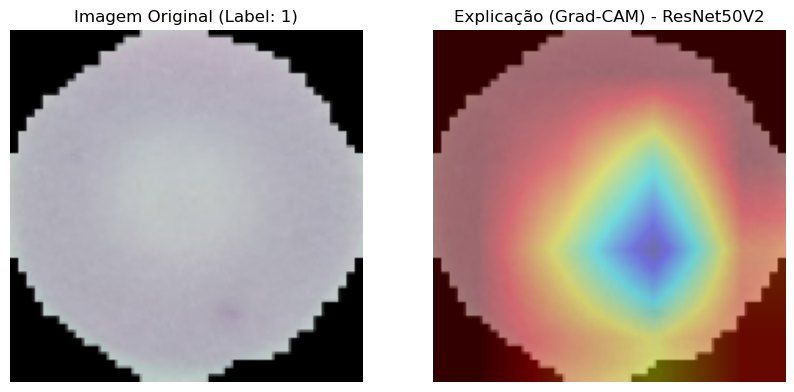

Salvando resultados para ResNet50V2.

--- BENCHMARK CONCLUÍDO ---


In [22]:
# ==============================================================================
# 5. O LOOP DE BENCHMARK (CORRIGIDO)
# ==============================================================================
# Contém a correção final: remover o model.load_model

# --- Configurações do Treino ---
EPOCHS = 40 # Máximo de épocas
PATIENCE = 5  # Paciência para o EarlyStopping
MODELS_TO_TEST = ["SimpleCNN", "MobileNetV2", "ResNet50V2"]

# --- Carregar os dados (apenas uma vez) ---
ds_train, ds_val, (X_calib, y_calib), (X_test, y_test) = get_datasets()

# --- Dicionário para guardar todos os resultados ---
benchmark_results = {}

print("\n--- INICIANDO O BENCHMARK DE MODELOS ---")

# Pega uma imagem de teste para o Grad-CAM (sempre a mesma)
idx_grad_cam = np.where(y_test == 1)[0][0]
img_grad_cam = X_test[idx_grad_cam:idx_grad_cam+1] # Mantém a dimensão do batch
label_grad_cam = y_test[idx_grad_cam]

for model_name in MODELS_TO_TEST:
    print(f"\n--- Testando Modelo: {model_name} ---")
    
    # 1. Limpar a sessão do Keras (para evitar nomes duplicados)
    keras.backend.clear_session()
    
    # 2. Construir o modelo
    builder_fn = MODEL_BUILDERS[model_name]
    model, grad_cam_layers = builder_fn()
    
    # 3. Definir Callbacks
    checkpoint_path = f"{model_name}_best.keras"
    model_checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True, # Isso SALVA o melhor modelo...
        verbose=0
    )
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True, # ...e isso RESTAURA o melhor modelo na memória
        verbose=1
    )
    
    # 4. Treinar o modelo
    print(f"Treinando {model_name} por até {EPOCHS} épocas (Paciência={PATIENCE})...")
    
    history = model.fit(
        ds_train,
        epochs=EPOCHS,
        validation_data=ds_val,
        callbacks=[early_stopping, model_checkpoint],
        verbose=1
    )
    
    # --- CORREÇÃO (Graph Disconnected) ---
    # A linha abaixo foi REMOVIDA. O `EarlyStopping` já restaurou
    # o melhor modelo na memória, e esse objeto 'model' ainda tem
    # o gráfico interno "vivo" para o Grad-CAM.
    
    # print(f"Carregando melhor modelo salvo de {checkpoint_path}...")
    # model = keras.models.load_model(checkpoint_path) # <-- ESTA LINHA CAUSA O ERRO
    
    # ------------------------------------
    
    # 5. Rodar Análise de Incerteza (Crepes)
    # Usamos o 'model' que já está na memória (com os melhores pesos)
    crepes_results = run_crepes_analysis(model, X_calib, y_calib, X_test, y_test)
    
    # 6. Rodar Análise de Explicabilidade (Grad-CAM)
    print("Gerando Grad-CAM...")
    plot_grad_cam(model, img_grad_cam, grad_cam_layers, label_grad_cam)
    
    # 7. Salvar tudo
    print(f"Salvando resultados para {model_name}.")
    benchmark_results[model_name] = {
        "model": model,
        "history": history.history,
        "crepes_results": crepes_results
    }

print("\n--- BENCHMARK CONCLUÍDO ---")


Carregando e dividindo datasets...
Dataset de Treino: 19291 imagens (pronto para streaming).
Dataset de Validação: 2755 imagens (pronto para streaming).
Set de Calibração: 2756 imagens (em RAM).
Set de Teste: 2756 imagens (em RAM).

--- INICIANDO O BENCHMARK DE MODELOS ---

--- Testando Modelo: SimpleCNN ---
Treinando SimpleCNN por até 40 épocas (Paciência=5)...
Epoch 1/40


2025-12-04 18:15:52.568536: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - ETA: 0s - loss: 0.6256 - accuracy: 0.6550

2025-12-04 18:16:18.849543: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - 28s 91ms/step - loss: 0.6256 - accuracy: 0.6550 - val_loss: 0.5215 - val_accuracy: 0.7368
Epoch 2/40
302/302 [==============================] - 25s 84ms/step - loss: 0.2435 - accuracy: 0.9075 - val_loss: 0.2106 - val_accuracy: 0.9223
Epoch 3/40
302/302 [==============================] - 24s 80ms/step - loss: 0.1639 - accuracy: 0.9386 - val_loss: 0.1710 - val_accuracy: 0.9394
Epoch 4/40
302/302 [==============================] - 24s 78ms/step - loss: 0.1271 - accuracy: 0.9520 - val_loss: 0.1805 - val_accuracy: 0.9448
Epoch 5/40
302/302 [==============================] - 25s 83ms/step - loss: 0.0920 - accuracy: 0.9645 - val_loss: 0.1932 - val_accuracy: 0.9314
Epoch 6/40
302/302 [==============================] - 25s 82ms/step - loss: 0.0713 - accuracy: 0.9717 - val_loss: 0.2537 - val_accuracy: 0.9379
Epoch 7/40
302/302 [==============================] - 24s 77ms/step - loss: 0.0486 - accuracy: 0.9806 - val_loss: 0.2486 - val_accuracy: 0.9292
Epo

2025-12-04 18:19:12.436296: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Prevendo conjuntos de teste...
Avaliando...
Cobertura: 0.9536, Tamanho Médio: 1.0399
Gerando Grad-CAM...


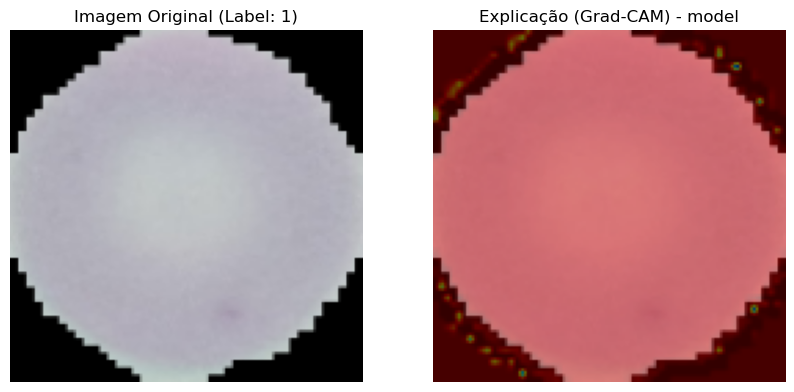

Salvando resultados para SimpleCNN.

--- Testando Modelo: MobileNetV2 ---


Treinando MobileNetV2 por até 40 épocas (Paciência=5)...
Epoch 1/40


2025-12-04 18:19:19.295514: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - ETA: 0s - loss: 0.1797 - accuracy: 0.9340

2025-12-04 18:19:47.742490: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - 34s 108ms/step - loss: 0.1797 - accuracy: 0.9340 - val_loss: 0.2770 - val_accuracy: 0.9071
Epoch 2/40
302/302 [==============================] - 32s 107ms/step - loss: 0.0981 - accuracy: 0.9660 - val_loss: 0.1615 - val_accuracy: 0.9517
Epoch 3/40
302/302 [==============================] - 32s 104ms/step - loss: 0.0649 - accuracy: 0.9781 - val_loss: 0.1652 - val_accuracy: 0.9528
Epoch 4/40
302/302 [==============================] - 31s 101ms/step - loss: 0.0428 - accuracy: 0.9850 - val_loss: 0.1793 - val_accuracy: 0.9477
Epoch 5/40
302/302 [==============================] - 31s 100ms/step - loss: 0.0275 - accuracy: 0.9911 - val_loss: 0.3479 - val_accuracy: 0.9191
Epoch 6/40
302/302 [==============================] - 31s 102ms/step - loss: 0.0199 - accuracy: 0.9938 - val_loss: 0.2498 - val_accuracy: 0.9506
Epoch 7/40
302/302 [==============================] - 31s 103ms/step - loss: 0.0128 - accuracy: 0.9961 - val_loss: 0.3076 - val_accuracy: 0.9

Iniciando análise Crepes para MobileNetV2...
Calibrando...


2025-12-04 18:23:02.484484: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Prevendo conjuntos de teste...
Avaliando...
Cobertura: 0.9528, Tamanho Médio: 1.0054
Gerando Grad-CAM...


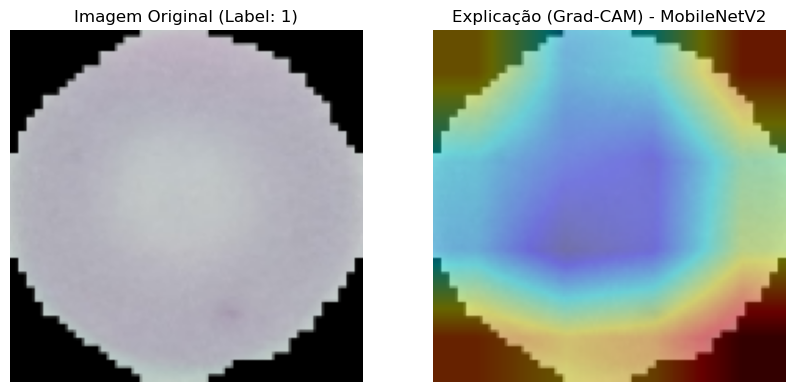

Salvando resultados para MobileNetV2.

--- Testando Modelo: ResNet50V2 ---
Treinando ResNet50V2 por até 40 épocas (Paciência=5)...
Epoch 1/40


2025-12-04 18:23:16.591022: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - ETA: 0s - loss: 0.1995 - accuracy: 0.9178

2025-12-04 18:24:33.326263: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


302/302 [==============================] - 89s 288ms/step - loss: 0.1995 - accuracy: 0.9178 - val_loss: 0.1581 - val_accuracy: 0.9452
Epoch 2/40
302/302 [==============================] - 88s 293ms/step - loss: 0.0680 - accuracy: 0.9745 - val_loss: 0.1673 - val_accuracy: 0.9477
Epoch 3/40
302/302 [==============================] - 86s 285ms/step - loss: 0.0258 - accuracy: 0.9912 - val_loss: 0.2193 - val_accuracy: 0.9426
Epoch 4/40
302/302 [==============================] - 84s 278ms/step - loss: 0.0241 - accuracy: 0.9916 - val_loss: 0.2353 - val_accuracy: 0.9488
Epoch 5/40
302/302 [==============================] - 82s 270ms/step - loss: 0.0203 - accuracy: 0.9932 - val_loss: 0.2181 - val_accuracy: 0.9535
Epoch 6/40
302/302 [==============================] - 80s 264ms/step - loss: 0.0131 - accuracy: 0.9952 - val_loss: 0.2341 - val_accuracy: 0.9514
Epoch 6: early stopping
Treino concluído. Recriando modelo e carregando melhores pesos...
Iniciando análise Crepes para ResNet50V2...
Calibra

2025-12-04 18:31:47.494712: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Prevendo conjuntos de teste...
Avaliando...
Cobertura: 0.9507, Tamanho Médio: 1.0138
Gerando Grad-CAM...


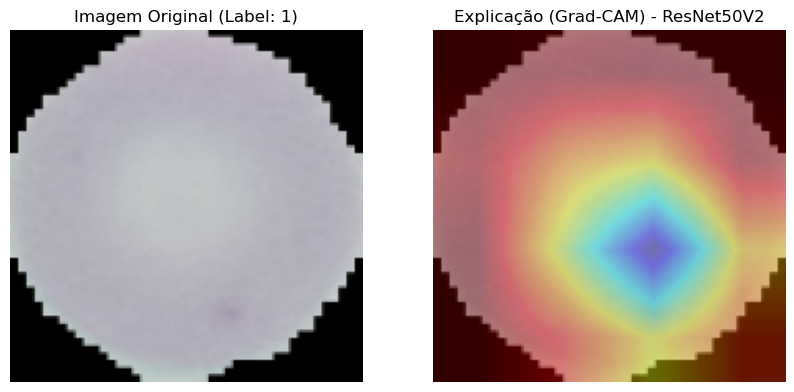

Salvando resultados para ResNet50V2.

--- BENCHMARK CONCLUÍDO ---


In [23]:
# ==============================================================================
# 5. O LOOP DE BENCHMARK (CORREÇÃO FINAL E ROBUSTA)
# ==============================================================================
# Carrega os PESOS em um modelo novo para evitar o "Graph Disconnected"

# --- Configurações do Treino ---
EPOCHS = 40 # Máximo de épocas
PATIENCE = 5  # Paciência para o EarlyStopping
MODELS_TO_TEST = ["SimpleCNN", "MobileNetV2", "ResNet50V2"] 

# --- Carregar os dados (apenas uma vez) ---
ds_train, ds_val, (X_calib, y_calib), (X_test, y_test) = get_datasets()

# --- Dicionário para guardar todos os resultados ---
benchmark_results = {}

print("\n--- INICIANDO O BENCHMARK DE MODELOS ---")

# Pega uma imagem de teste para o Grad-CAM (sempre a mesma)
idx_grad_cam = np.where(y_test == 1)[0][0]
img_grad_cam = X_test[idx_grad_cam:idx_grad_cam+1] # Mantém a dimensão do batch
label_grad_cam = y_test[idx_grad_cam]

for model_name in MODELS_TO_TEST:
    print(f"\n--- Testando Modelo: {model_name} ---")
    
    # 1. Limpar a sessão do Keras
    keras.backend.clear_session()
    
    # 2. Construir o modelo (1ª vez, para treinar)
    builder_fn = MODEL_BUILDERS[model_name]
    model_to_train, grad_cam_layers = builder_fn()
    
    # 3. Definir Callbacks
    checkpoint_path = f"{model_name}_best.keras"
    model_checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True, # Salva o melhor modelo em arquivo
        save_weights_only=True, # --- SALVAR APENAS OS PESOS ---
        verbose=0
    )
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=False, # --- NÃO RESTAURAR (pois quebra o gráfico) ---
        verbose=1
    )
    
    # 4. Treinar o modelo
    print(f"Treinando {model_name} por até {EPOCHS} épocas (Paciência={PATIENCE})...")
    
    history = model_to_train.fit(
        ds_train,
        epochs=EPOCHS,
        validation_data=ds_val,
        callbacks=[early_stopping, model_checkpoint],
        verbose=1
    )
    
    # --- CORREÇÃO DEFINITIVA (Graph Disconnected) ---
    print("Treino concluído. Recriando modelo e carregando melhores pesos...")
    
    # 1. Limpar tudo
    keras.backend.clear_session()
    
    # 2. Recriar a arquitetura do modelo (limpa)
    model, grad_cam_layers = builder_fn()
    
    # 3. Carregar APENAS os pesos (isso não quebra o gráfico)
    model.load_weights(checkpoint_path)
    # -----------------------------------------------
    
    
    # 5. Rodar Análise de Incerteza (Crepes)
    # Usamos o novo 'model' com os pesos carregados
    crepes_results = run_crepes_analysis(model, X_calib, y_calib, X_test, y_test)
    
    # 6. Rodar Análise de Explicabilidade (Grad-CAM)
    print("Gerando Grad-CAM...")
    plot_grad_cam(model, img_grad_cam, grad_cam_layers, label_grad_cam)
    
    # 7. Salvar tudo
    print(f"Salvando resultados para {model_name}.")
    benchmark_results[model_name] = {
        "model": model, # Salva o modelo "correto"
        "history": history.history,
        "crepes_results": crepes_results
    }

print("\n--- BENCHMARK CONCLUÍDO ---")


--- Análise Comparativa dos Modelos ---


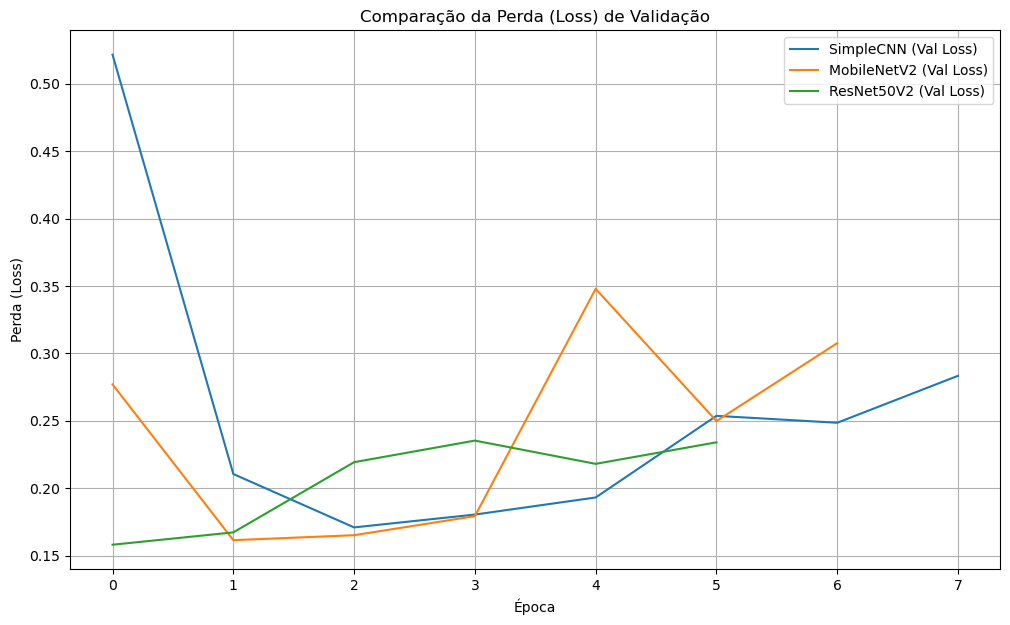


--- Resumo das Métricas ---
             Melhor Época  Best Val Loss  Best Val Acc  Cobertura Crepes  \
Modelo                                                                     
SimpleCNN               3         0.1710        0.9394            0.9536   
MobileNetV2             2         0.1615        0.9517            0.9528   
ResNet50V2              1         0.1581        0.9452            0.9507   

             Tamanho Médio Set  
Modelo                          
SimpleCNN               1.0399  
MobileNetV2             1.0054  
ResNet50V2              1.0138  

--- Análise de Z-Score ---
(Valores positivos altos são bons para Acc/Cobertura; Negativos altos são bons para Loss/Tamanho)
             Best Val Loss_zscore  Best Val Acc_zscore  \
Modelo                                                   
SimpleCNN                    1.12                -0.98   
MobileNetV2                 -0.31                 1.02   
ResNet50V2                  -0.81                -0.04   

        

In [24]:
# ==============================================================================
# 6. ANÁLISE FINAL E COMPARAÇÃO (COM Z-SCORE)
# ==============================================================================

print("\n--- Análise Comparativa dos Modelos ---")

# --- 1. Plotar Curvas de Perda (Loss) ---
plt.figure(figsize=(12, 7))
for model_name, results in benchmark_results.items():
    # Pega a 'val_loss' do histórico
    val_loss = results["history"]["val_loss"]
    # Plota
    plt.plot(val_loss, label=f"{model_name} (Val Loss)")
plt.title("Comparação da Perda (Loss) de Validação")
plt.xlabel("Época")
plt.ylabel("Perda (Loss)")
plt.legend()
plt.grid(True)
plt.show()

# --- 2. Criar DataFrame com Métricas-Chave ---
summary_data = []
for model_name, results in benchmark_results.items():
    history = results["history"]
    crepes = results["crepes_results"]
    
    # Pega as métricas do melhor ponto (graças ao EarlyStopping)
    best_epoch = np.argmin(history['val_loss'])
    
    summary_data.append({
        "Modelo": model_name,
        "Melhor Época": best_epoch + 1,
        "Best Val Loss": history['val_loss'][best_epoch],
        "Best Val Acc": history['val_accuracy'][best_epoch],
        "Cobertura Crepes": crepes["coverage"],
        "Tamanho Médio Set": crepes["avg_set_size"]
    })

df = pd.DataFrame(summary_data)
df.set_index("Modelo", inplace=True)

print("\n--- Resumo das Métricas ---")
# Usamos .round(4) para formatar a tabela
print(df.round(4))

# --- 3. Análise de Z-Score (como você pediu) ---
# O Z-Score nos diz quantos desvios padrão um modelo está
# da média, para cada métrica.

# Copia o dataframe para não modificar o original
df_zscore = df.copy()

# Para 'loss' e 'tamanho', menos é melhor
# Para 'acc' e 'cobertura', mais é melhor
metrics_to_normalize = ["Best Val Loss", "Best Val Acc", "Cobertura Crepes", "Tamanho Médio Set"]

for col in metrics_to_normalize:
    # Z-Score = (valor - média) / desvio_padrão
    col_zscore = f"{col}_zscore"
    mean = df[col].mean()
    std = df[col].std()
    
    # Evita divisão por zero se todos os valores forem iguais
    if std == 0:
        df_zscore[col_zscore] = 0.0
    else:
        df_zscore[col_zscore] = (df[col] - mean) / std

print("\n--- Análise de Z-Score ---")
print("(Valores positivos altos são bons para Acc/Cobertura; Negativos altos são bons para Loss/Tamanho)")
zscore_cols = [col for col in df_zscore.columns if "zscore" in col]
print(df_zscore[zscore_cols].round(2))


--- Gerando e Salvando Visualizações em 'resultados_benchmark' ---
Gerando curva de calibração para SimpleCNN...


2025-12-04 18:32:14.062758: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Gerando curva de calibração para MobileNetV2...


2025-12-04 18:32:44.782221: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Gerando curva de calibração para ResNet50V2...


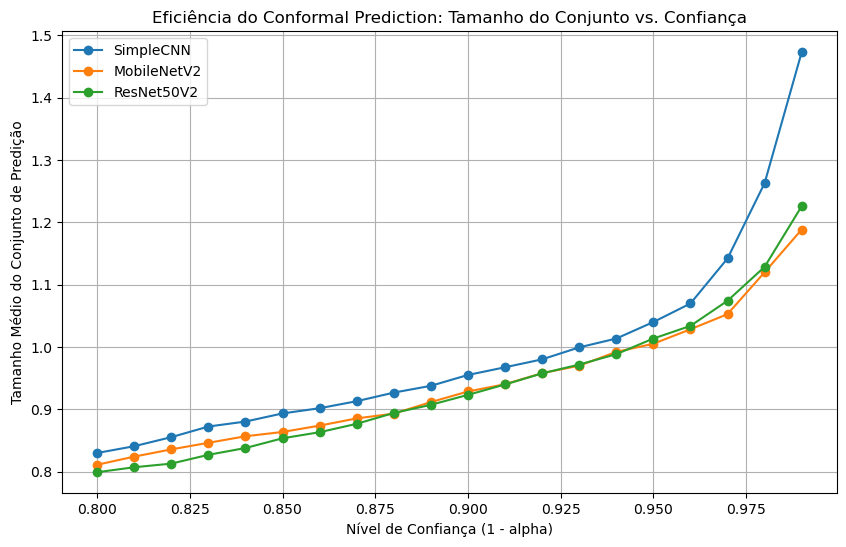

Gráfico de eficiência conformal salvo.

Gerando painel comparativo de Grad-CAM para 6 imagens...


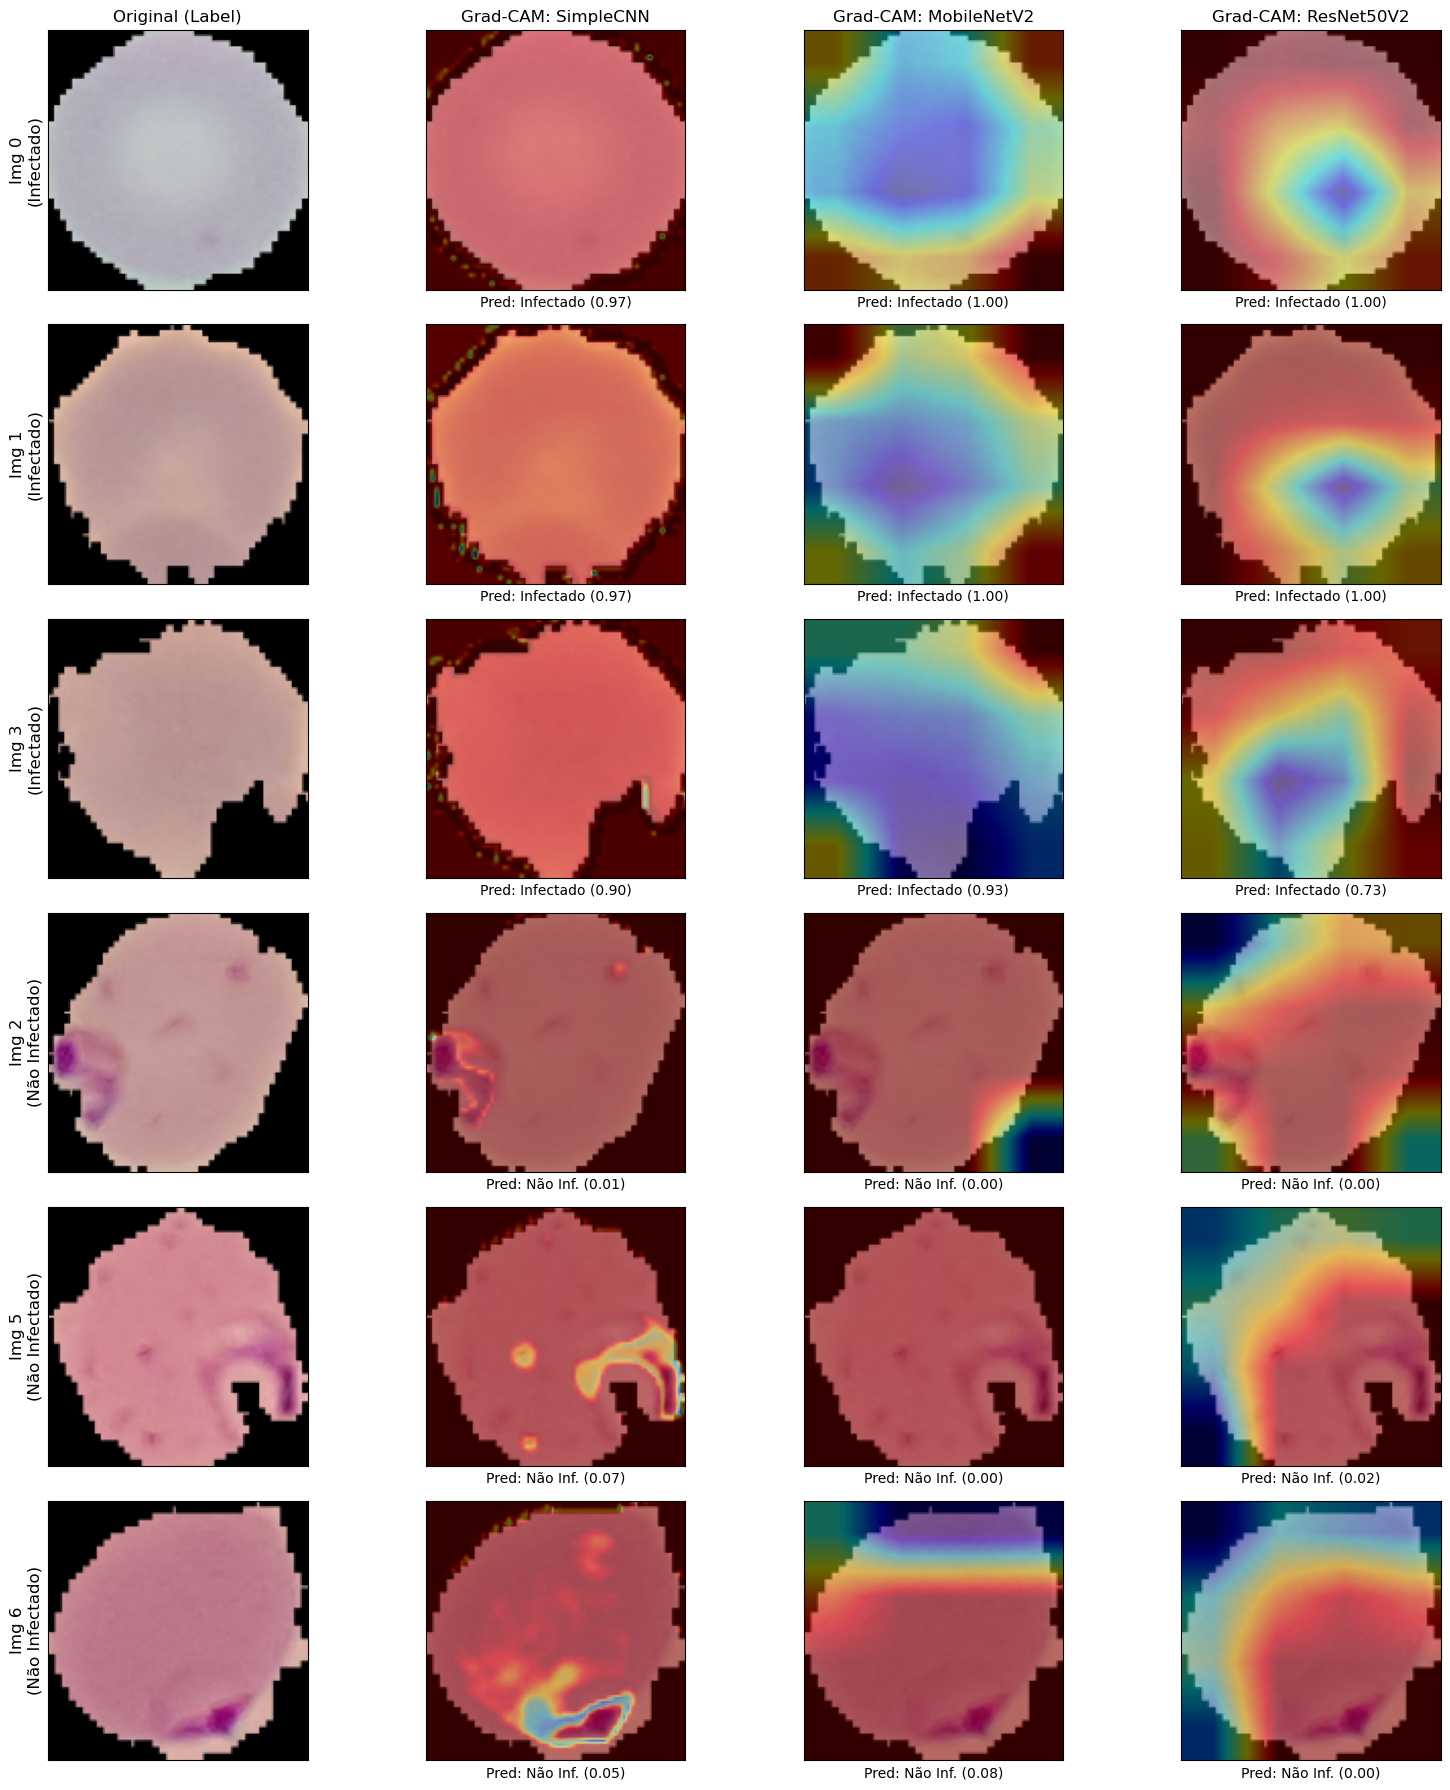

Painel comparativo de Grad-CAM salvo.

--- GERAÇÃO DE RESULTADOS CONCLUÍDA ---
Verifique a pasta 'resultados_benchmark' para os arquivos gerados.


In [25]:
# ==============================================================================
# 7. VISUALIZAÇÕES DETALHADAS E SALVAMENTO
# ==============================================================================
import os

# Cria diretório para salvar as figuras
OUTPUT_DIR = "resultados_benchmark"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print(f"\n--- Gerando e Salvando Visualizações em '{OUTPUT_DIR}' ---")

# --- A. Gráficos de Cobertura vs. Tamanho do Conjunto (Conformal Prediction) ---
# Para cada modelo, vamos gerar um gráfico mostrando como o tamanho do conjunto varia
# com diferentes níveis de confiança (além do 95% padrão).

confidence_levels = np.linspace(0.8, 0.99, 20)

plt.figure(figsize=(10, 6))

for model_name, results in benchmark_results.items():
    model = results["model"]
    # Precisamos recalibrar/prever para vários níveis de confiança
    # Recupera os dados de calibração e teste (já carregados no escopo global)
    # Nota: O ideal seria ter guardado o objeto 'cp' no dicionário de resultados,
    # mas podemos recriá-lo rapidamente.
    
    print(f"Gerando curva de calibração para {model_name}...")
    keras_adapter = KerasWrapper(model)
    cp = WrapClassifier(learner=keras_adapter)
    cp.calibrate(X=X_calib, y=y_calib)
    
    avg_set_sizes = []
    for conf in confidence_levels:
        y_sets = cp.predict_set(X=X_test, confidence=conf)
        # Calcula tamanho médio
        sizes = y_sets.sum(axis=1)
        avg_set_sizes.append(sizes.mean())
        
    plt.plot(confidence_levels, avg_set_sizes, marker='o', label=model_name)

plt.xlabel("Nível de Confiança (1 - alpha)")
plt.ylabel("Tamanho Médio do Conjunto de Predição")
plt.title("Eficiência do Conformal Prediction: Tamanho do Conjunto vs. Confiança")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "conformal_efficiency.png"))
plt.show()
print("Gráfico de eficiência conformal salvo.")


# --- B. Comparação Visual de Grad-CAM (Explicabilidade) ---
# Vamos pegar algumas imagens de teste (ex: 3 infectadas, 3 não infectadas)
# e gerar o Grad-CAM para todos os modelos lado a lado.

# Seleciona índices de exemplo
idx_infected = np.where(y_test == 1)[0][:3]
idx_uninfected = np.where(y_test == 0)[0][:3]
sample_indices = np.concatenate([idx_infected, idx_uninfected])

print(f"\nGerando painel comparativo de Grad-CAM para {len(sample_indices)} imagens...")

# Configura o plot: Linhas = Imagens, Colunas = Original + Modelos
n_cols = 1 + len(MODELS_TO_TEST)
fig, axes = plt.subplots(len(sample_indices), n_cols, figsize=(4 * n_cols, 3 * len(sample_indices)))

# Títulos das colunas
axes[0, 0].set_title("Original (Label)", fontsize=12)
for i, model_name in enumerate(MODELS_TO_TEST):
    axes[0, i+1].set_title(f"Grad-CAM: {model_name}", fontsize=12)

for row_idx, img_idx in enumerate(sample_indices):
    # Dados da imagem
    img_array = X_test[img_idx:img_idx+1] # (1, 128, 128, 3)
    original_label = y_test[img_idx]
    label_str = "Infectado" if original_label == 1 else "Não Infectado"
    
    # 1. Plot Original
    original_img_uint8 = img_array[0].astype('uint8')
    axes[row_idx, 0].imshow(original_img_uint8)
    axes[row_idx, 0].set_ylabel(f"Img {img_idx}\n({label_str})", rotation=90, size='large')
    axes[row_idx, 0].set_xticks([])
    axes[row_idx, 0].set_yticks([])
    
    # 2. Plot Grad-CAM para cada modelo
    for col_idx, model_name in enumerate(MODELS_TO_TEST):
        model = benchmark_results[model_name]["model"]
        
        # Determina a camada alvo (baseado na nossa fábrica)
        if model_name == "SimpleCNN":
            layer_name = "conv2d_1" # Ajuste se mudou na fábrica
        elif model_name == "MobileNetV2":
            layer_name = ("MobileNetV2", "out_relu") # Tupla para nested
        elif model_name == "ResNet50V2":
            layer_name = ("ResNet50V2", "conv5_block3_out") # Tupla para nested
            
        # Gera o heatmap
        try:
            heatmap = get_grad_cam_final(model, img_array, layer_name)
            
            # Processa para visualização
            heatmap = np.array(heatmap)
            if heatmap.max() > 0: # Evita divisão por zero em imagens pretas/sem ativação
                heatmap = heatmap / heatmap.max()
                
            heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
            heatmap_resized = np.uint8(255 * heatmap_resized)
            heatmap_resized = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
            
            superimposed = cv2.addWeighted(original_img_uint8, 0.6, heatmap_resized, 0.4, 0)
            
            axes[row_idx, col_idx+1].imshow(superimposed)
            
            # Adiciona a predição do modelo no título ou label
            pred_prob = model.predict(img_array, verbose=0)[0][0]
            pred_label = "Infectado" if pred_prob > 0.5 else "Não Inf."
            axes[row_idx, col_idx+1].set_xlabel(f"Pred: {pred_label} ({pred_prob:.2f})")
            
        except Exception as e:
            print(f"Erro no Grad-CAM para {model_name}, img {img_idx}: {e}")
            axes[row_idx, col_idx+1].text(0.5, 0.5, "Erro Grad-CAM", ha='center')
            
        axes[row_idx, col_idx+1].set_xticks([])
        axes[row_idx, col_idx+1].set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_comparison_panel.png"))
plt.show()
print("Painel comparativo de Grad-CAM salvo.")

print("\n--- GERAÇÃO DE RESULTADOS CONCLUÍDA ---")
print(f"Verifique a pasta '{OUTPUT_DIR}' para os arquivos gerados.")